# Montagu Letters — Noun Frequency & Sentiment/Emotion Visualizations

Two simple visualizations:
1. Top 12 nouns in English vs French letters
2. Emotion breakdown (Hartmann) + sentiment trend across letters (Siebert)

Run cells in order. The data is loaded directly from your CSVs, so re-running
after re-generating those files will refresh the charts automatically.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- File paths: adjust if your CSVs live elsewhere ---
POS_PATH = "../../output/montagu_lemmatized_pos.csv"
SENTIMENT_PATH = "../../output/montagu_letters_siebert_sentiment.csv"
EMOTION_PATH = "../../output/montagu_letters_hartmann_emotion_full.csv"

## 1. Top nouns — English vs French

In [5]:
df_pos = pd.read_csv(POS_PATH)

# A few non-content tokens worth excluding (editorial markers / negation particles)
# we can adjust this
exclude_en = {"sic"}
exclude_fr = {"point"}

en_nouns = df_pos[(df_pos["language"] == "en") & (df_pos["pos"] == "NOUN") & (~df_pos["lemma"].isin(exclude_en))]
fr_nouns = df_pos[(df_pos["language"] == "fr") & (df_pos["pos"] == "NOUN") & (~df_pos["lemma"].isin(exclude_fr))]

top_en = en_nouns["lemma"].value_counts().head(30)
top_fr = fr_nouns["lemma"].value_counts().head(30)

print("Top EN nouns:")
print(top_en)
print()
print("Top FR nouns:")
print(top_fr)

Top EN nouns:
lemma
lady        124
person      101
house       100
day          95
town         93
man          87
part         83
time         83
woman        81
place        71
thing        71
country      67
head         63
letter       63
manner       62
court        62
world        61
beauty       55
pleasure     53
hand         52
sort         47
year         47
side         45
night        43
face         43
number       41
eye          41
body         41
account      40
journey      38
Name: count, dtype: int64

Top FR nouns:
lemma
femme       157
ville       113
homme        81
pays         79
jour         75
maison       74
turc         71
tem          70
lettre       65
monde        59
cour         58
plaisir      57
dames        51
œil          50
chose        49
côté         46
air          46
empereur     46
maniere      45
tête         45
usage        45
présent      45
chambre      44
doute        42
chere        42
habit        42
an           42
beauté       41
parti

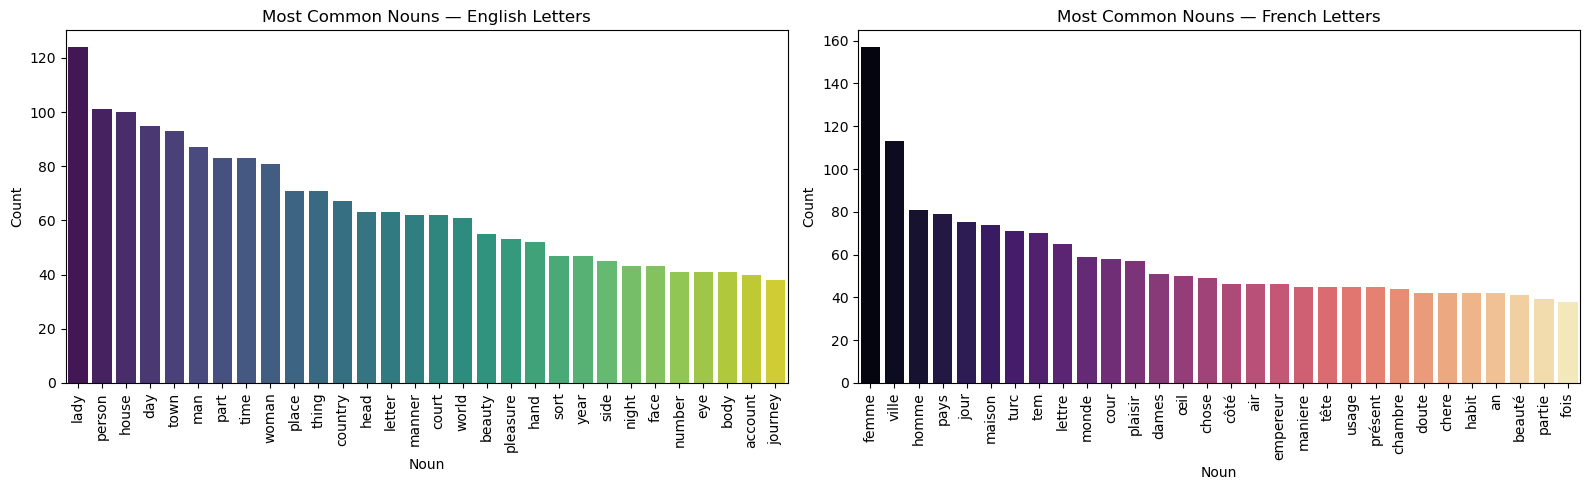

In [8]:
# Visualize top nouns — English vs French, side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=top_en.index, y=top_en.values, hue=top_en.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Most Common Nouns — English Letters")
axes[0].set_xlabel("Noun")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)

sns.barplot(x=top_fr.index, y=top_fr.values, hue=top_fr.index, palette="magma", legend=False, ax=axes[1])
axes[1].set_title("Most Common Nouns — French Letters")
axes[1].set_xlabel("Noun")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## 2. Emotion breakdown + sentiment trend across letters

In [12]:
df_sent = pd.read_csv(SENTIMENT_PATH)
df_emo = pd.read_csv(EMOTION_PATH)

# Overall emotion counts (Hartmann)
emo_counts = df_emo["top_emotion"].value_counts()
print("Emotion counts:")
print(emo_counts)
print()

# Per-letter % positive sentiment, in chronological/written order (Siebert)
sent_by_letter = (df_sent.groupby("letter_idx")["pred"].mean() * 100).round(1)
print("Letters covered:", df_sent["letter_idx"].nunique())
print(sent_by_letter.head())

# Overall % positive vs % negative across all sentences
sentiment_pct = df_sent["label"].value_counts(normalize=True) * 100

print(sentiment_pct.round(1))

Emotion counts:
top_emotion
neutral     1523
disgust      338
joy          255
sadness      141
surprise     126
anger        102
fear          94
Name: count, dtype: int64

Letters covered: 52
letter_idx
0    66.7
1    66.7
2    66.7
3    41.7
4    55.6
Name: pred, dtype: float64
label
POSITIVE    63.2
NEGATIVE    36.8
Name: proportion, dtype: float64


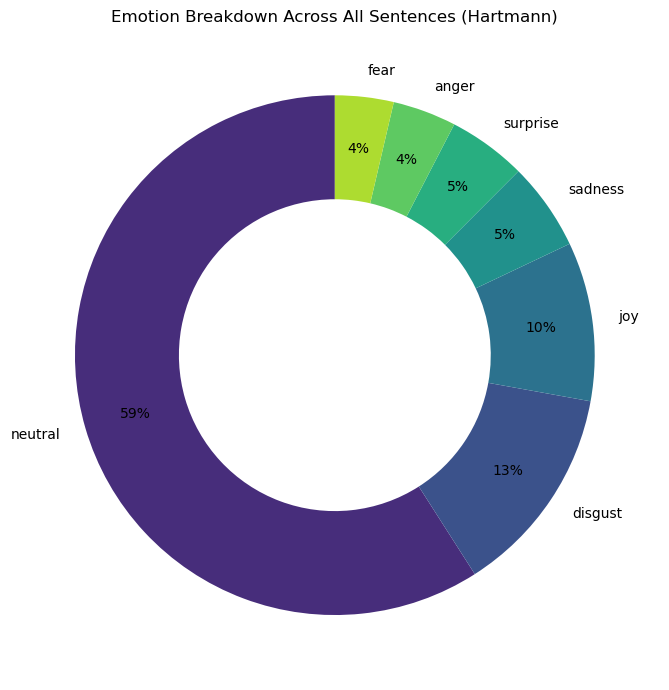

In [ ]:
# Use a seaborn color palette for consistency with your other charts
colors = sns.color_palette("viridis", len(emo_counts))

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    emo_counts.values,
    labels=emo_counts.index,
    autopct='%1.0f%%',
    colors=colors,
    wedgeprops=dict(width=0.4),  # this creates the donut hole
    pctdistance=0.8,
    startangle=90
)

ax.set_title("Emotion Breakdown Across All Sentences (Hartmann)")
plt.tight_layout()
plt.show()

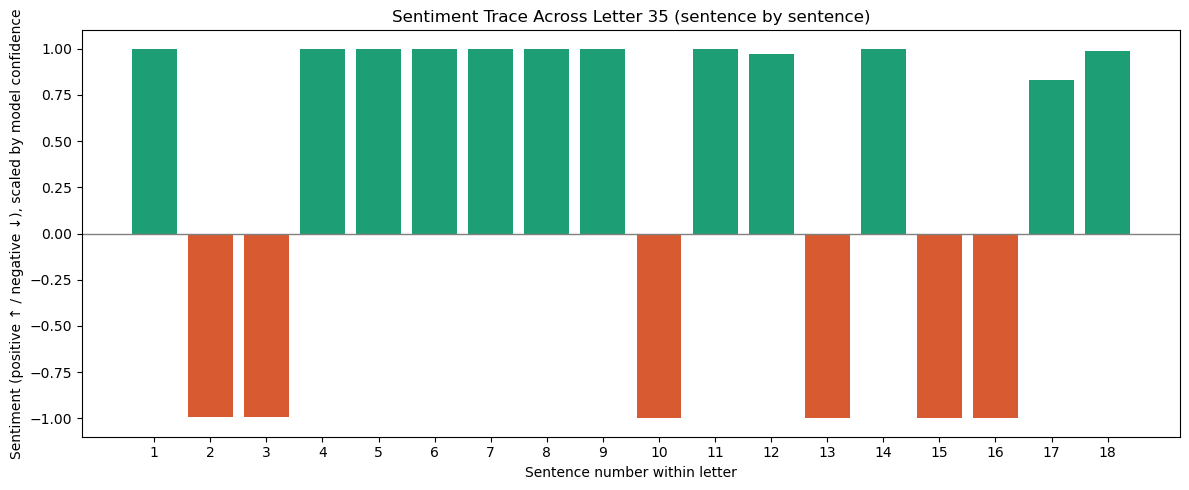

In [13]:
# ============================================================
# Chart 1: Sentiment trace across letter 35, sentence by sentence
# ============================================================
letter35 = df_sent[df_sent["letter_idx"] == 35].reset_index(drop=True)
letter35["sentence_num"] = letter35.index + 1

# signed score: positive bars go up, negative bars go down,
# height scaled by the model's confidence in that prediction
letter35["signed_score"] = letter35.apply(
    lambda r: r["score"] if r["label"] == "POSITIVE" else -r["score"], axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = letter35["signed_score"].apply(lambda v: "#1D9E75" if v > 0 else "#D85A30")
ax.bar(letter35["sentence_num"], letter35["signed_score"], color=colors)
ax.axhline(0, color="gray", linewidth=1)
ax.set_title("Sentiment Trace Across Letter 35 (sentence by sentence)")
ax.set_xlabel("Sentence number within letter")
ax.set_ylabel("Sentiment (positive ↑ / negative ↓), scaled by model confidence")
ax.set_xticks(letter35["sentence_num"])
plt.tight_layout()
plt.show()

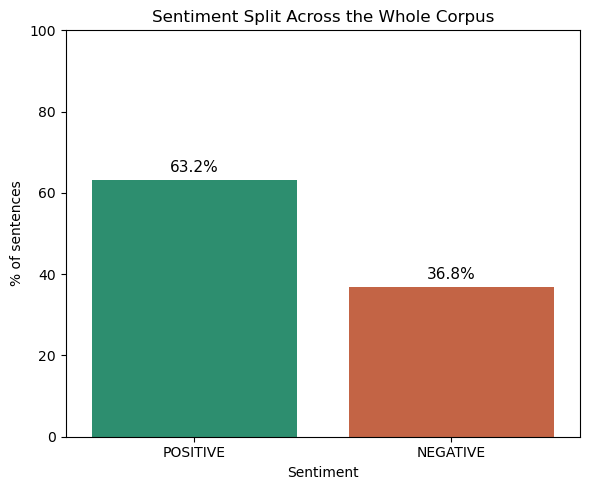

In [14]:
# ============================================================
# Chart 2: % positive vs % negative across the WHOLE corpus
# ============================================================
sentiment_pct = df_sent["label"].value_counts(normalize=True) * 100

fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.barplot(
    x=sentiment_pct.index, y=sentiment_pct.values, hue=sentiment_pct.index,
    palette=["#1D9E75", "#D85A30"], legend=False, ax=ax2
)
ax2.set_title("Sentiment Split Across the Whole Corpus")
ax2.set_xlabel("Sentiment")
ax2.set_ylabel("% of sentences")
ax2.set_ylim(0, 100)

for i, v in enumerate(sentiment_pct.values):
    ax2.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

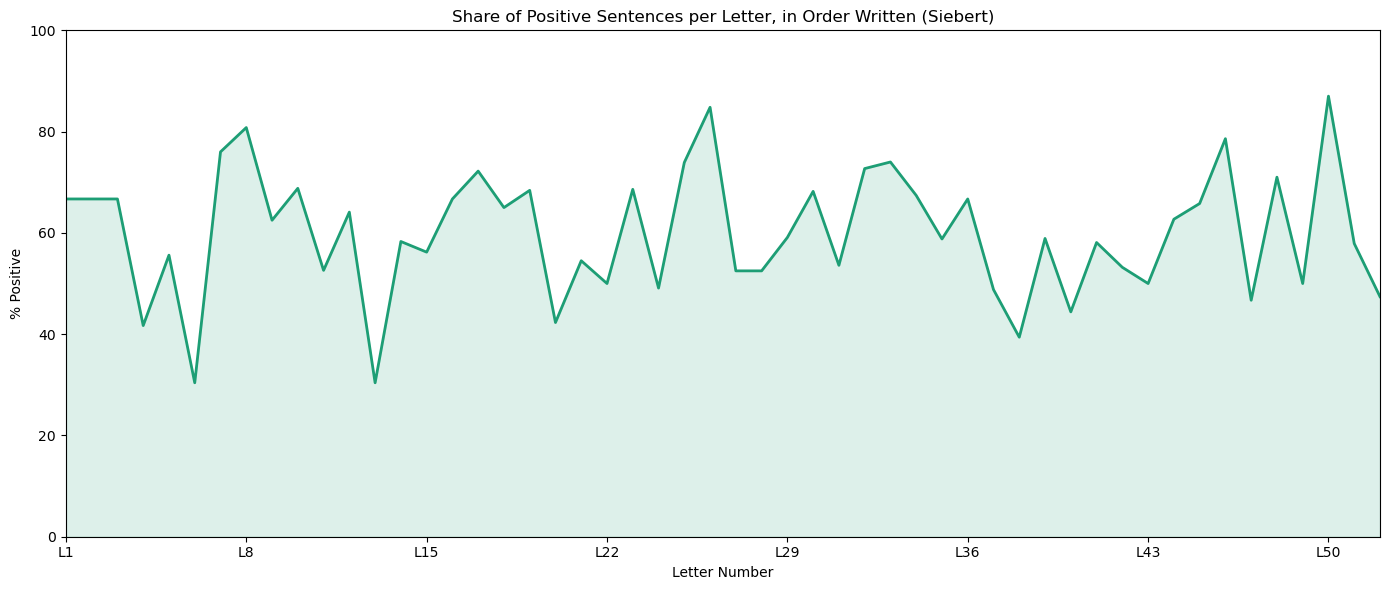

In [15]:
sent_by_letter = (df_sent.groupby("letter_idx")["pred"].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(sent_by_letter.index + 1, sent_by_letter.values, color="#1D9E75", linewidth=2)
ax.fill_between(sent_by_letter.index + 1, sent_by_letter.values, color="#1D9E75", alpha=0.15)

ax.set_title("Share of Positive Sentences per Letter, in Order Written (Siebert)")
ax.set_xlabel("Letter Number")
ax.set_ylabel("% Positive")
ax.set_ylim(0, 100)
ax.set_xlim(1, 52)
ax.set_xticks(range(1, 53, 7))  # L1, L8, L15, ... similar spacing to your screenshot
ax.set_xticklabels([f"L{i}" for i in range(1, 53, 7)])

plt.tight_layout()
plt.show()